# EDA — BTC 5-Minute Up/Down Markets (Polymarket)

Exploratory analysis of ~9 000 resolved BTC 5-minute binary prediction markets, enriched with second-by-second BTC prices and individual trade data.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Load & inspect

In [28]:
df = pd.read_csv("../data/processed/btc_5m_full.csv", parse_dates=["event_datetime", "date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (9181, 27)


,slug,event_timestamp,event_datetime,date,hour,minute,day_of_week,winner,winner_binary,volume,...,btc_high,btc_low,btc_return,btc_volatility,btc_range,n_trades,n_unique_traders,total_trade_size,avg_trade_price,up_buy_pct
0,btc-updown-5m-1770856800,1770856800,2026-02-12 00:40:00+00:00,2026-02-12,0,40,Thursday,Up,1,7.000000,...,67588.83,67512.12,0.001065,0.000051,0.001136,2,1,95.0000,0.9900,1.0
1,btc-updown-5m-1770857100,1770857100,2026-02-12 00:45:00+00:00,2026-02-12,0,45,Thursday,Down,0,117.500000,...,67680.00,67500.77,-0.000829,0.000075,0.002652,2,1,117.5000,0.9900,0.0
2,btc-updown-5m-1770857400,1770857400,2026-02-12 00:50:00+00:00,2026-02-12,0,50,Thursday,Up,1,17.500000,...,67552.01,67493.77,0.000058,0.000071,0.000862,1,1,17.5000,0.9900,1.0
3,btc-updown-5m-1770857700,1770857700,2026-02-12 00:55:00+00:00,2026-02-12,0,55,Thursday,Down,0,0.000000,...,67597.08,67460.74,-0.001141,0.000079,0.002019,1,1,17.5000,0.9900,0.0
4,btc-updown-5m-1770858000,1770858000,2026-02-12 01:00:00+00:00,2026-02-12,1,0,Thursday,Up,1,47.429329,...,67607.44,67465.47,0.001238,0.000093,0.002104,5,4,163.3092,0.3198,0.6


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9181 entries, 0 to 9180
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   slug              9181 non-null   object             
 1   event_timestamp   9181 non-null   int64              
 2   event_datetime    9181 non-null   datetime64[ns, UTC]
 3   date              9181 non-null   datetime64[ns]     
 4   hour              9181 non-null   int64              
 5   minute            9181 non-null   int64              
 6   day_of_week       9181 non-null   object             
 7   winner            9181 non-null   object             
 8   winner_binary     9181 non-null   int64              
 9   volume            9181 non-null   float64            
 10  last_trade_price  9078 non-null   float64            
 11  best_bid          7164 non-null   float64            
 12  best_ask          9181 non-null   float64            
 13  spr

In [30]:
df.describe()

,event_timestamp,date,hour,minute,winner_binary,volume,last_trade_price,best_bid,best_ask,spread,...,btc_high,btc_low,btc_return,btc_volatility,btc_range,n_trades,n_unique_traders,total_trade_size,avg_trade_price,up_buy_pct
count,9.181000e+03,9181,9181.000000,9181.000000,9181.000000,9181.000000,9078.000000,7164.000000,9181.000000,9181.000000,...,9181.000000,9181.000000,9181.000000,9.181000e+03,9.181000e+03,9181.000000,9181.000000,9.181000e+03,9181.000000,9181.000000
mean,1.772234e+09,2026-02-27 11:13:48.537196288,11.478161,27.501362,0.513996,74768.701082,0.507270,0.640512,0.512905,0.012828,...,68341.208056,68197.801693,0.000008,7.116073e-05,2.103599e-03,1835.112188,577.194750,1.196280e+05,0.529926,0.417551
min,1.770857e+09,2026-02-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.001000,0.001000,0.001000,0.000900,...,62893.360000,62513.150000,-0.018300,1.000000e-07,1.500000e-07,1.000000,1.000000,1.750000e+01,0.061600,0.000000
25%,1.771545e+09,2026-02-19 00:00:00,5.000000,15.000000,0.000000,0.000000,0.010000,0.320000,0.030000,0.009000,...,67060.440000,66919.160000,-0.000734,4.193000e-05,1.103920e-03,1423.000000,503.000000,8.914246e+04,0.502500,0.387200
50%,1.772234e+09,2026-02-27 00:00:00,11.000000,30.000000,1.000000,80521.906255,0.520000,0.740000,0.510000,0.010000,...,68103.990000,67997.120000,0.000010,6.075000e-05,1.710330e-03,1791.000000,581.000000,1.113059e+05,0.543300,0.415800
75%,1.772922e+09,2026-03-07 00:00:00,17.000000,40.000000,1.000000,117248.276373,0.990000,0.990000,0.980000,0.010000,...,69857.580000,69730.660000,0.000747,8.753000e-05,2.634230e-03,2211.000000,659.000000,1.387305e+05,0.575100,0.446600
max,1.773611e+09,2026-03-15 00:00:00,23.000000,55.000000,1.000000,714113.221655,0.999000,0.999000,1.000000,0.980000,...,74040.330000,73722.070000,0.018543,5.137700e-04,2.368769e-02,4000.000000,1109.000000,1.299410e+06,0.990000,1.000000
std,7.951412e+05,NaN,6.902345,17.260756,0.499831,67724.968824,0.474205,0.354253,0.410227,0.025014,...,2106.566008,2108.161864,0.001689,4.394056e-05,1.545274e-03,606.652091,136.980112,5.525949e+04,0.076792,0.047518


In [31]:
df.isnull().sum()

slug                   0
event_timestamp        0
event_datetime         0
date                   0
hour                   0
minute                 0
day_of_week            0
winner                 0
winner_binary          0
volume                 0
last_trade_price     103
best_bid            2017
best_ask               0
spread                 0
closed                 0
btc_open               0
btc_close              0
btc_high               0
btc_low                0
btc_return             0
btc_volatility         0
btc_range              0
n_trades               0
n_unique_traders       0
total_trade_size       0
avg_trade_price        0
up_buy_pct             0
dtype: int64

## 2. Outcome distribution (Up vs Down)

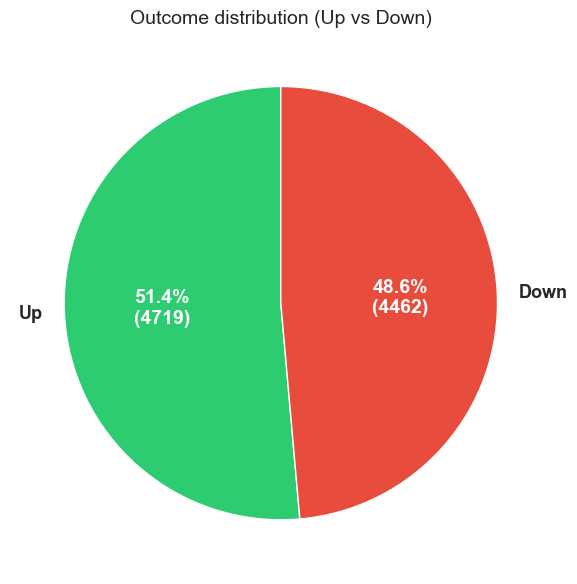

In [32]:
winner_counts = df["winner"].value_counts()

colors = {"Up": "#2ecc71", "Down": "#e74c3c"}

def make_label(pct, counts=winner_counts):
    absolute = int(round(pct / 100.0 * counts.sum()))
    return f"{pct:.1f}%\n({absolute})"

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    winner_counts,
    labels=winner_counts.index,
    colors=[colors[w] for w in winner_counts.index],
    autopct=lambda pct: make_label(pct),
    startangle=90,
    pctdistance=0.55,
    textprops={"fontsize": 13, "fontweight": "bold"},
)
for t in autotexts:
    t.set_color("white")
    t.set_fontsize(14)

ax.set_title("Outcome distribution (Up vs Down)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Volume analysis

Total volume traded: $686,451,445
Mean per market:     $74,769
Median per market:   $80,522


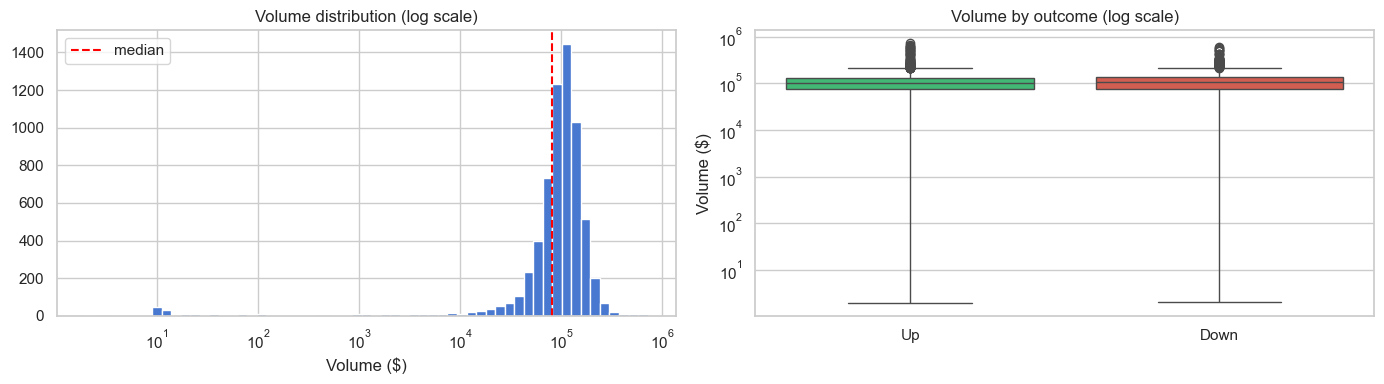

In [33]:
print(f"Total volume traded: ${df['volume'].sum():,.0f}")
print(f"Mean per market:     ${df['volume'].mean():,.0f}")
print(f"Median per market:   ${df['volume'].median():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vol_positive = df["volume"][df["volume"] > 0]
log_bins = np.logspace(np.log10(vol_positive.min()), np.log10(vol_positive.max()), 60)
axes[0].hist(vol_positive, bins=log_bins, edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Volume distribution (log scale)")
axes[0].set_xlabel("Volume ($)")
axes[0].axvline(df["volume"].median(), color="red", ls="--", label="median")
axes[0].legend()

df_pos = df[df["volume"] > 0]
sns.boxplot(data=df_pos, x="winner", y="volume", hue="winner", ax=axes[1],
            palette={"Up": "#2ecc71", "Down": "#e74c3c"}, legend=False)
axes[1].set_yscale("log")
axes[1].set_title("Volume by outcome (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Volume ($)")

plt.tight_layout()
plt.show()

## 4. Volume over time

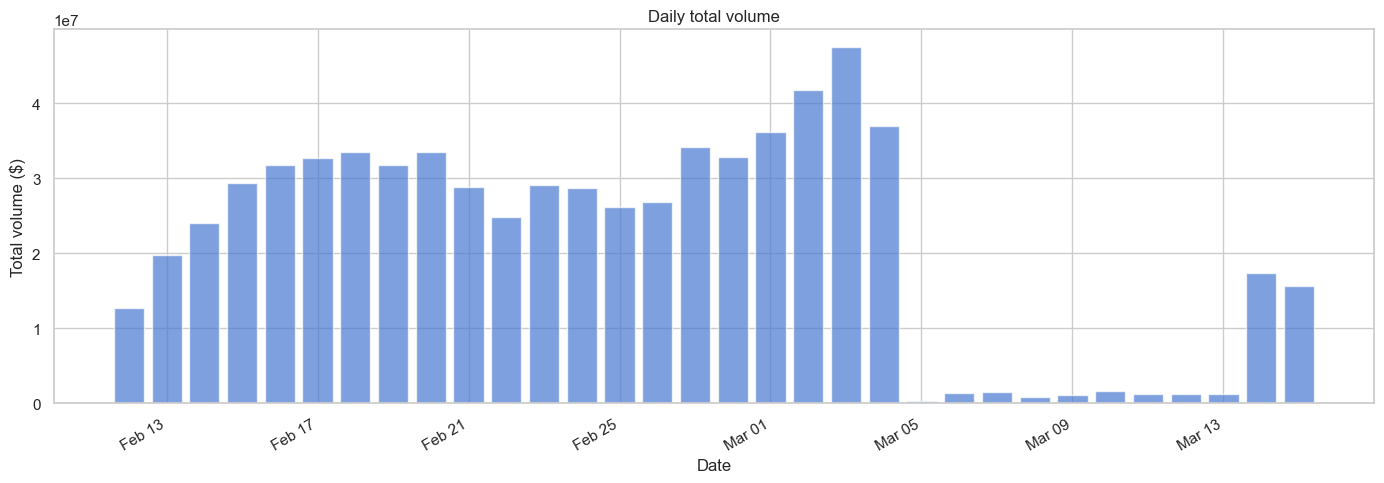

In [34]:
daily_vol = df.groupby("date")["volume"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_vol.index, daily_vol.values, alpha=0.7)
ax.set_ylabel("Total volume ($)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
ax.set_title("Daily total volume")
plt.tight_layout()
plt.show()

## 5. Temporal patterns

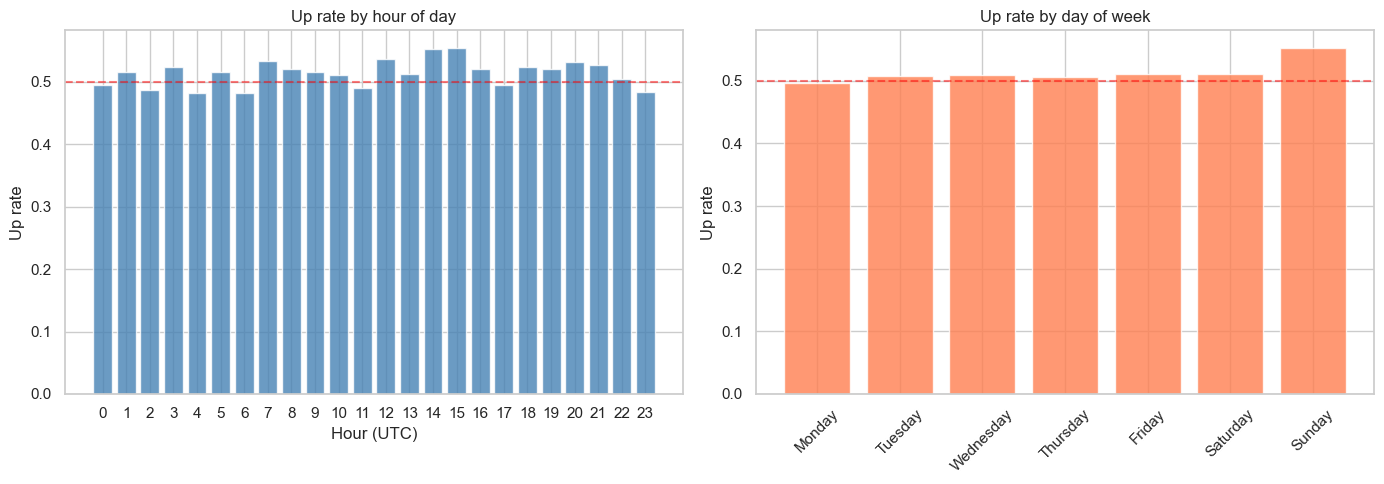

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby("hour").agg(
    up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count"),
    avg_volume=("volume", "mean")
)
axes[0].bar(hourly.index, hourly["up_rate"], color="steelblue", alpha=0.8)
axes[0].axhline(0.5, color="red", ls="--", alpha=0.5)
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Up rate")
axes[0].set_title("Up rate by hour of day")
axes[0].set_xticks(range(0, 24))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("day_of_week").agg(
    up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count")
).reindex(day_order)
axes[1].bar(daily.index, daily["up_rate"], color="coral", alpha=0.8)
axes[1].axhline(0.5, color="red", ls="--", alpha=0.5)
axes[1].set_ylabel("Up rate")
axes[1].set_title("Up rate by day of week")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

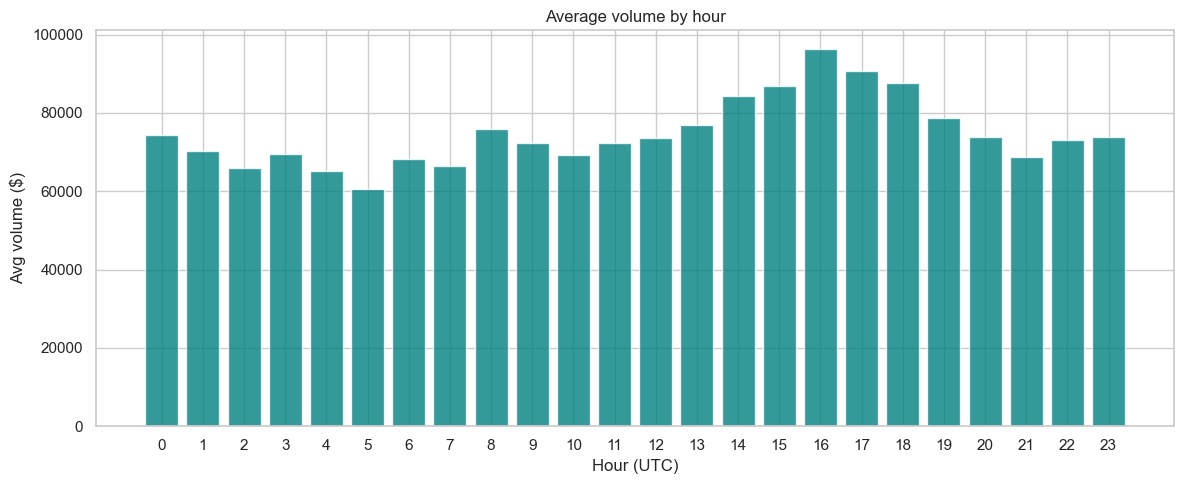

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly.index, hourly["avg_volume"], color="teal", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Avg volume ($)")
ax.set_title("Average volume by hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 6. BTC price analysis

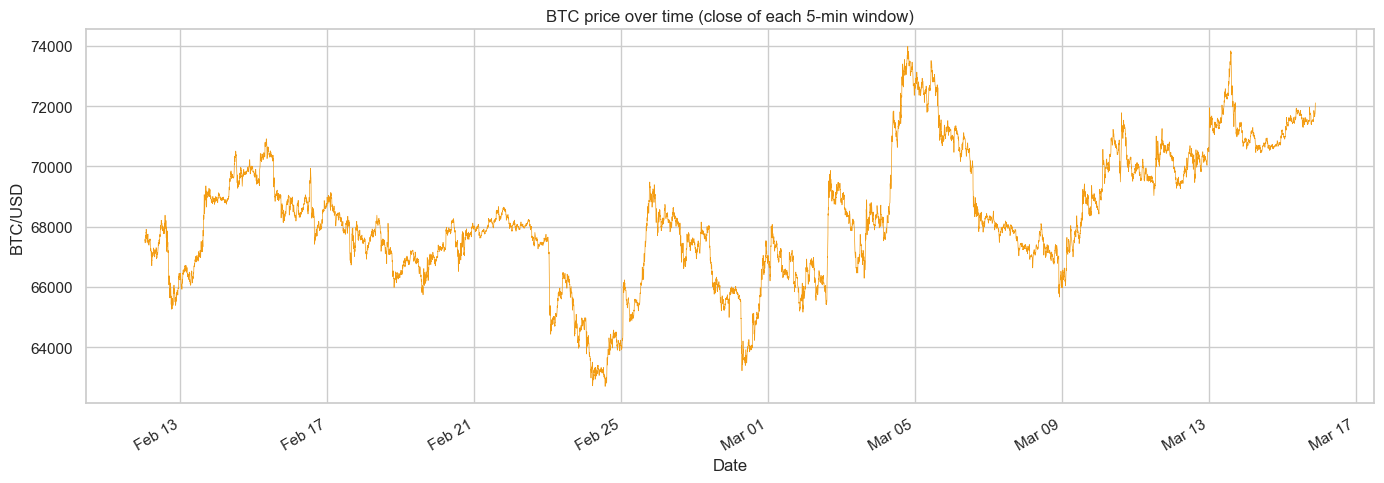

In [37]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["event_datetime"], df["btc_close"], linewidth=0.5, color="#f39c12")
ax.set_title("BTC price over time (close of each 5-min window)")
ax.set_ylabel("BTC/USD")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

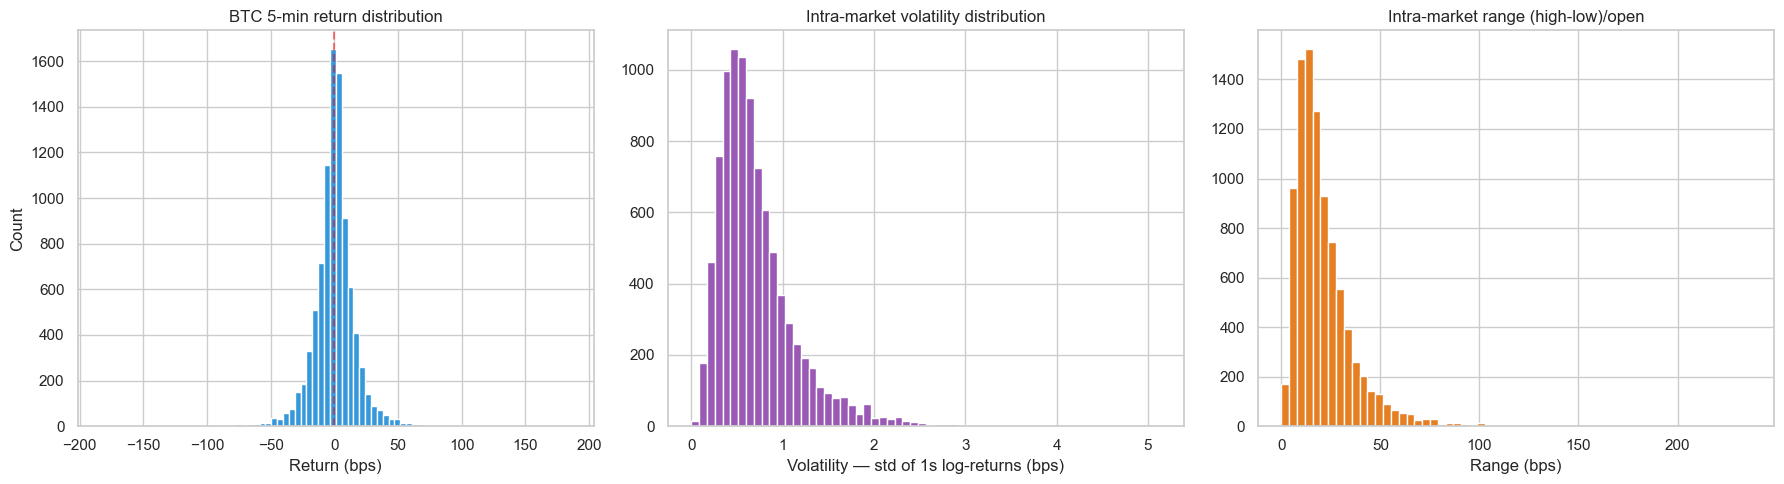

Mean return:     0.08 bps
Std return:      16.89 bps
Mean volatility: 0.71 bps
Mean range:      21.04 bps


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Return distribution
returns_bps = df["btc_return"] * 10000
axes[0].hist(returns_bps, bins=80, edgecolor="white", color="#3498db")
axes[0].axvline(0, color="red", ls="--", alpha=0.5)
axes[0].set_title("BTC 5-min return distribution")
axes[0].set_xlabel("Return (bps)")
axes[0].set_ylabel("Count")

# Volatility distribution
vol_data = df["btc_volatility"] * 10000
axes[1].hist(vol_data, bins=60, edgecolor="white", color="#9b59b6")
axes[1].set_title("Intra-market volatility distribution")
axes[1].set_xlabel("Volatility — std of 1s log-returns (bps)")

# Range distribution
range_bps = df["btc_range"] * 10000
axes[2].hist(range_bps, bins=60, edgecolor="white", color="#e67e22")
axes[2].set_title("Intra-market range (high-low)/open")
axes[2].set_xlabel("Range (bps)")

plt.tight_layout()
plt.show()

print(f"Mean return:     {df['btc_return'].mean()*10000:.2f} bps")
print(f"Std return:      {df['btc_return'].std()*10000:.2f} bps")
print(f"Mean volatility: {df['btc_volatility'].mean()*10000:.2f} bps")
print(f"Mean range:      {df['btc_range'].mean()*10000:.2f} bps")

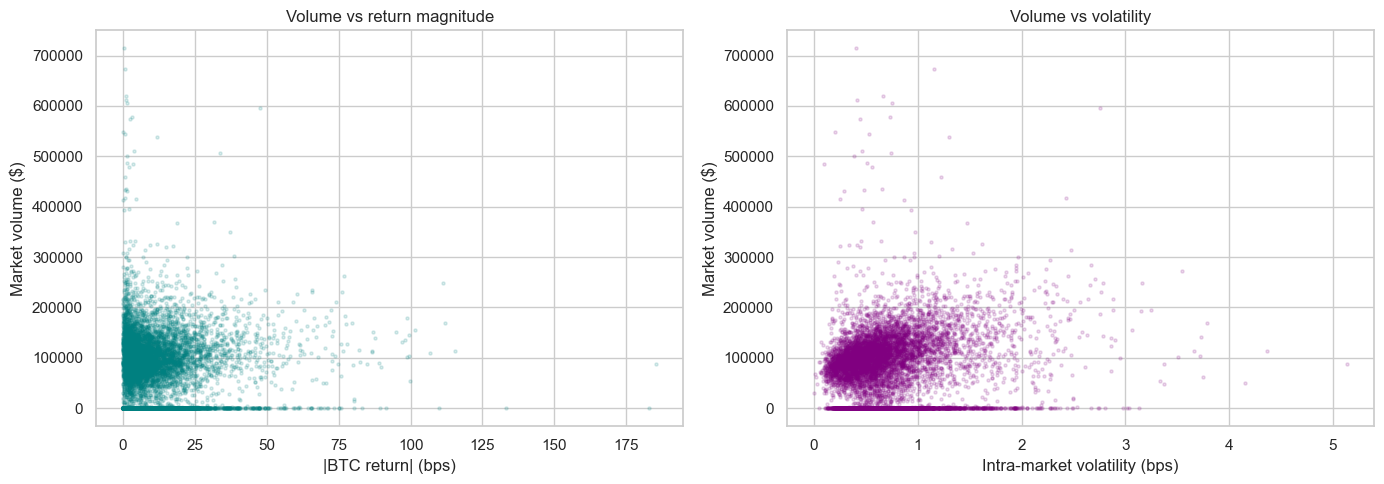

Correlation |return| vs volume: 0.032
Correlation volatility vs volume: 0.169


In [39]:
# Return magnitude vs volume
df["abs_return_bps"] = df["btc_return"].abs() * 10000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["abs_return_bps"], df["volume"], alpha=0.15, s=5, color="teal")
axes[0].set_xlabel("|BTC return| (bps)")
axes[0].set_ylabel("Market volume ($)")
axes[0].set_title("Volume vs return magnitude")

axes[1].scatter(df["btc_volatility"] * 10000, df["volume"], alpha=0.15, s=5, color="purple")
axes[1].set_xlabel("Intra-market volatility (bps)")
axes[1].set_ylabel("Market volume ($)")
axes[1].set_title("Volume vs volatility")

plt.tight_layout()
plt.show()

print(f"Correlation |return| vs volume: {df['abs_return_bps'].corr(df['volume']):.3f}")
print(f"Correlation volatility vs volume: {(df['btc_volatility']*10000).corr(df['volume']):.3f}")

## 7. Trade activity analysis

Total trades:         16,848,165
Mean trades/market:   1835.1
Median trades/market: 1791
Mean unique traders:  577.2


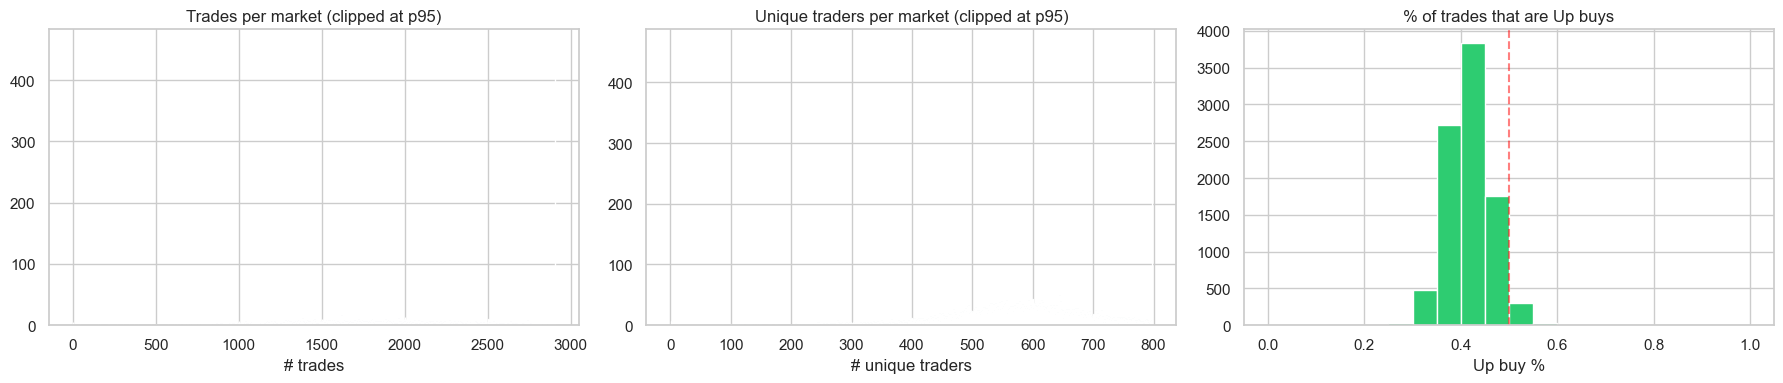

In [40]:
print(f"Total trades:         {df['n_trades'].sum():,}")
print(f"Mean trades/market:   {df['n_trades'].mean():.1f}")
print(f"Median trades/market: {df['n_trades'].median():.0f}")
print(f"Mean unique traders:  {df['n_unique_traders'].mean():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

trade_max = int(df["n_trades"].quantile(0.95))
axes[0].hist(df["n_trades"].clip(upper=trade_max), bins=range(0, trade_max + 2),
             edgecolor="white", color="#2c3e50")
axes[0].set_title("Trades per market (clipped at p95)")
axes[0].set_xlabel("# trades")

trader_max = int(df["n_unique_traders"].quantile(0.95))
axes[1].hist(df["n_unique_traders"].clip(upper=trader_max), bins=range(0, trader_max + 2),
             edgecolor="white", color="#16a085")
axes[1].set_title("Unique traders per market (clipped at p95)")
axes[1].set_xlabel("# unique traders")

up_buy = df["up_buy_pct"].dropna()
axes[2].hist(up_buy, bins=20, edgecolor="white", color="#2ecc71")
axes[2].axvline(0.5, color="red", ls="--", alpha=0.5)
axes[2].set_title("% of trades that are Up buys")
axes[2].set_xlabel("Up buy %")

plt.tight_layout()
plt.show()

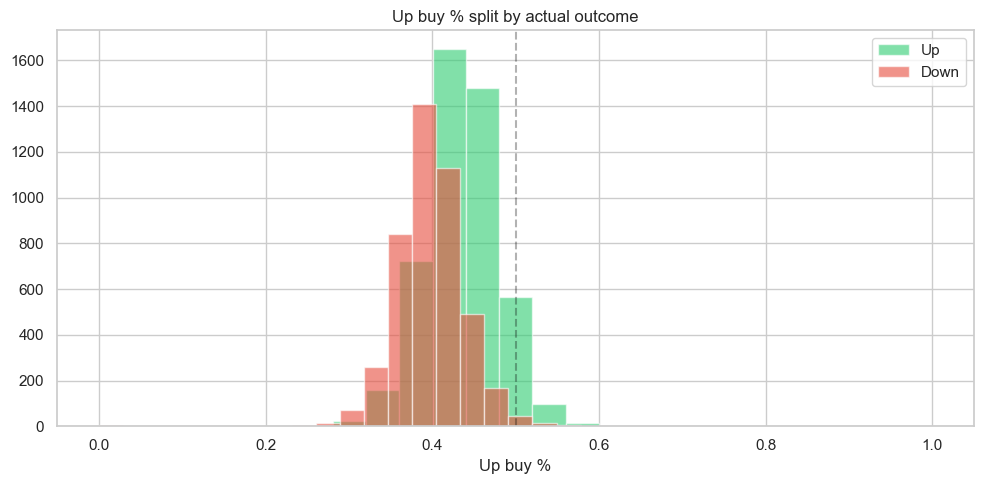

In [41]:
# Up buy % vs actual outcome
df_with_trades = df[df["n_trades"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [("Up", "#2ecc71"), ("Down", "#e74c3c")]:
    subset = df_with_trades[df_with_trades["winner"] == label]
    ax.hist(subset["up_buy_pct"], bins=20, alpha=0.6, label=label, color=color, edgecolor="white")
ax.axvline(0.5, color="black", ls="--", alpha=0.3)
ax.set_title("Up buy % split by actual outcome")
ax.set_xlabel("Up buy %")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Last trade price & calibration

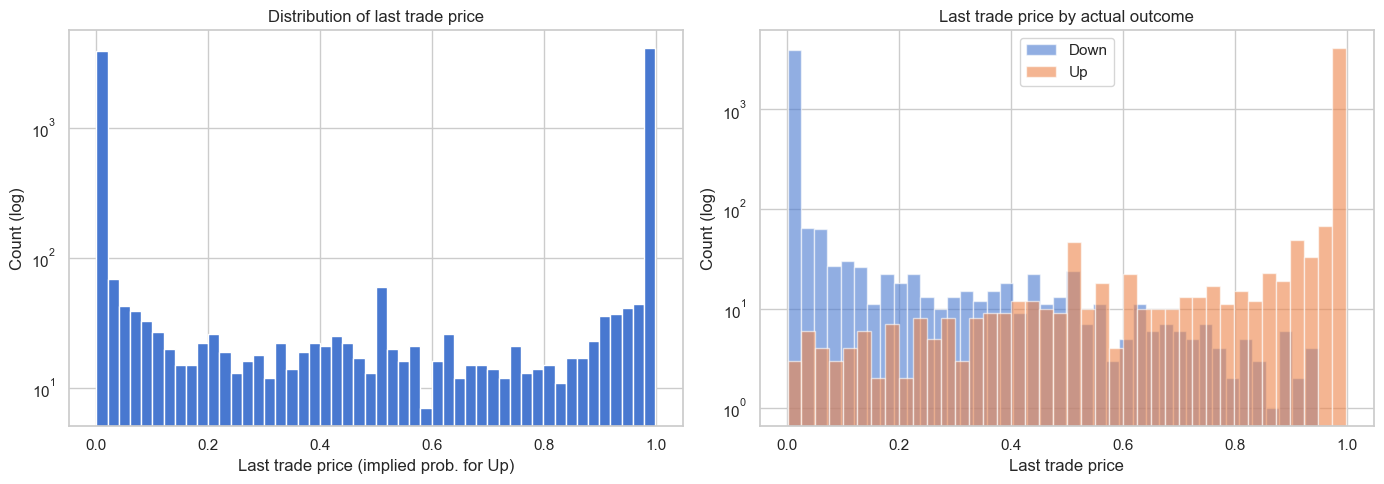

In [42]:
df_ltp = df.dropna(subset=["last_trade_price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_ltp["last_trade_price"].hist(bins=50, ax=axes[0], edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Distribution of last trade price")
axes[0].set_xlabel("Last trade price (implied prob. for Up)")
axes[0].set_ylabel("Count (log)")

for label, group in df_ltp.groupby("winner"):
    axes[1].hist(group["last_trade_price"], bins=40, alpha=0.6, label=label, edgecolor="white")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("Last trade price by actual outcome")
axes[1].set_xlabel("Last trade price")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

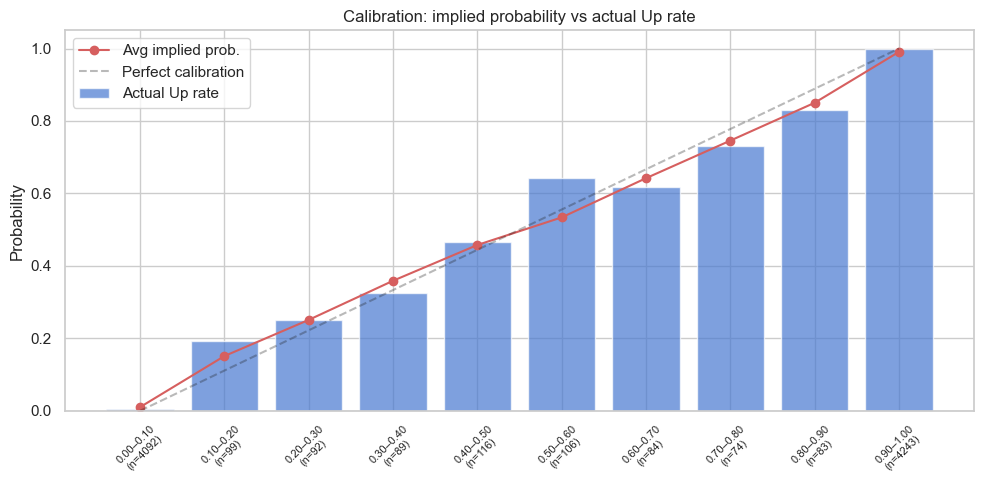

In [43]:
# Calibration
df_cal = df_ltp.copy()
df_cal["price_bucket"] = pd.cut(df_cal["last_trade_price"], bins=10)
cal = df_cal.groupby("price_bucket", observed=True).agg(
    actual_up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count"),
    avg_price=("last_trade_price", "mean")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(cal)), cal["actual_up_rate"], alpha=0.7, label="Actual Up rate")
ax.plot(range(len(cal)), cal["avg_price"], "ro-", label="Avg implied prob.")
ax.plot([0, len(cal)-1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")
ax.set_xticks(range(len(cal)))
ax.set_xticklabels([f"{iv.left:.2f}\u2013{iv.right:.2f}\n(n={n})" for iv, n in zip(cal.index, cal["count"])],
                   fontsize=8, rotation=45)
ax.set_ylabel("Probability")
ax.set_title("Calibration: implied probability vs actual Up rate")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Spread & market efficiency

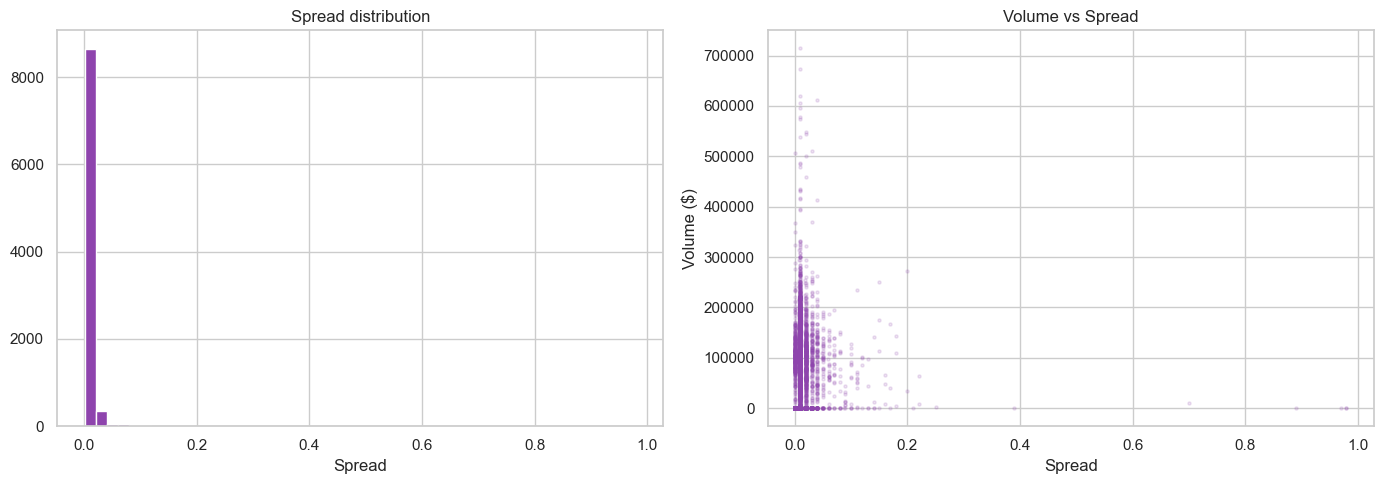

Mean spread:   0.013
Median spread: 0.010


In [44]:
df_spread = df.dropna(subset=["spread"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_spread["spread"].hist(bins=50, ax=axes[0], edgecolor="white", color="#8e44ad")
axes[0].set_title("Spread distribution")
axes[0].set_xlabel("Spread")

# Spread vs volume
axes[1].scatter(df_spread["spread"], df_spread["volume"], alpha=0.15, s=5, color="#8e44ad")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Volume ($)")
axes[1].set_title("Volume vs Spread")

plt.tight_layout()
plt.show()

print(f"Mean spread:   {df_spread['spread'].mean():.3f}")
print(f"Median spread: {df_spread['spread'].median():.3f}")

## 10. Streaks & autocorrelation

Number of streaks: 4677
Longest Up streak:   126
Longest Down streak: 14
Mean streak length:  1.96


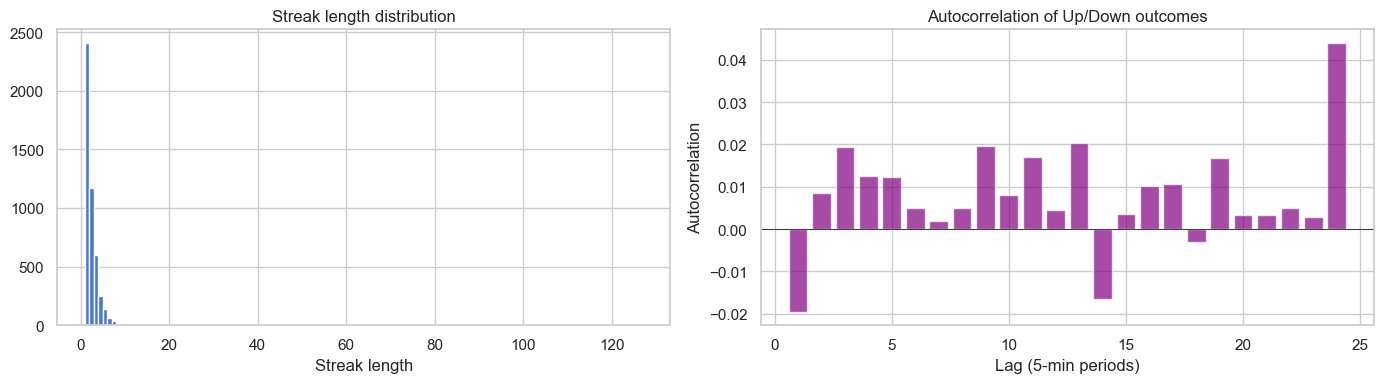

In [45]:
df_sorted = df.sort_values("event_timestamp")
outcomes = df_sorted["winner_binary"].values

streaks = []
current, length = outcomes[0], 1
for o in outcomes[1:]:
    if o == current:
        length += 1
    else:
        streaks.append(("Up" if current == 1 else "Down", length))
        current, length = o, 1
streaks.append(("Up" if current == 1 else "Down", length))

streak_df = pd.DataFrame(streaks, columns=["direction", "length"])
print(f"Number of streaks: {len(streak_df)}")
print(f"Longest Up streak:   {streak_df[streak_df['direction']=='Up']['length'].max()}")
print(f"Longest Down streak: {streak_df[streak_df['direction']=='Down']['length'].max()}")
print(f"Mean streak length:  {streak_df['length'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

streak_df["length"].hist(bins=range(1, streak_df["length"].max()+2), ax=axes[0], edgecolor="white")
axes[0].set_title("Streak length distribution")
axes[0].set_xlabel("Streak length")

lags = range(1, 25)
autocorrs = [pd.Series(outcomes).autocorr(lag=l) for l in lags]
axes[1].bar(lags, autocorrs, color="purple", alpha=0.7)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of Up/Down outcomes")
axes[1].set_xlabel("Lag (5-min periods)")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## 11. Heatmap: Up rate by hour × day of week

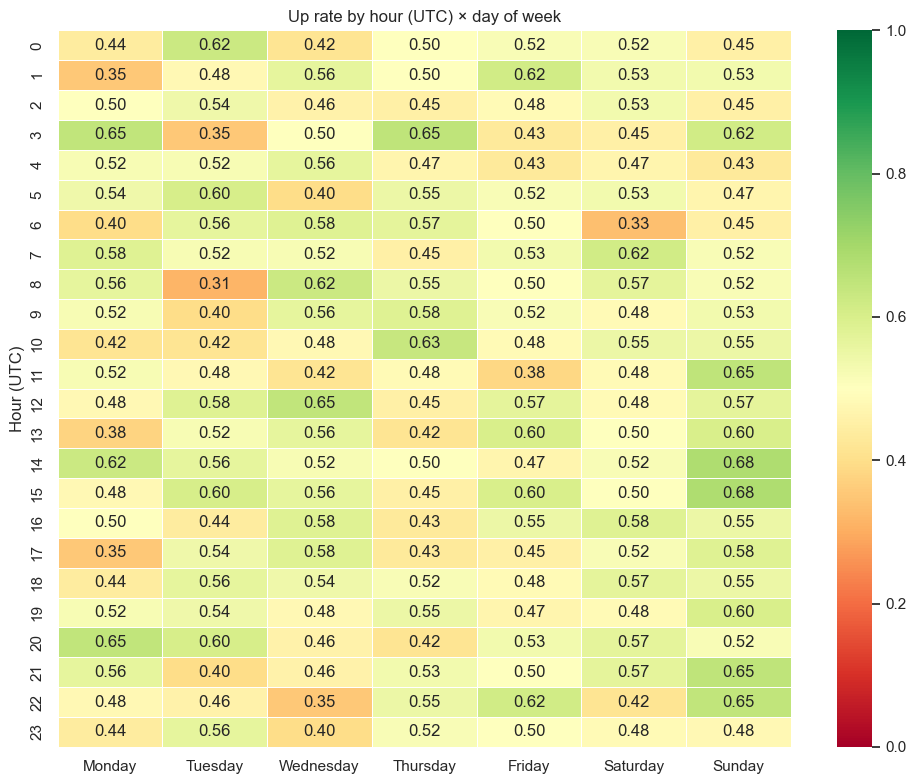

In [46]:
pivot = df.pivot_table(values="winner_binary", index="hour", columns="day_of_week",
                       aggfunc="mean")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Up rate by hour (UTC) × day of week")
ax.set_ylabel("Hour (UTC)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 12. Volatility over time

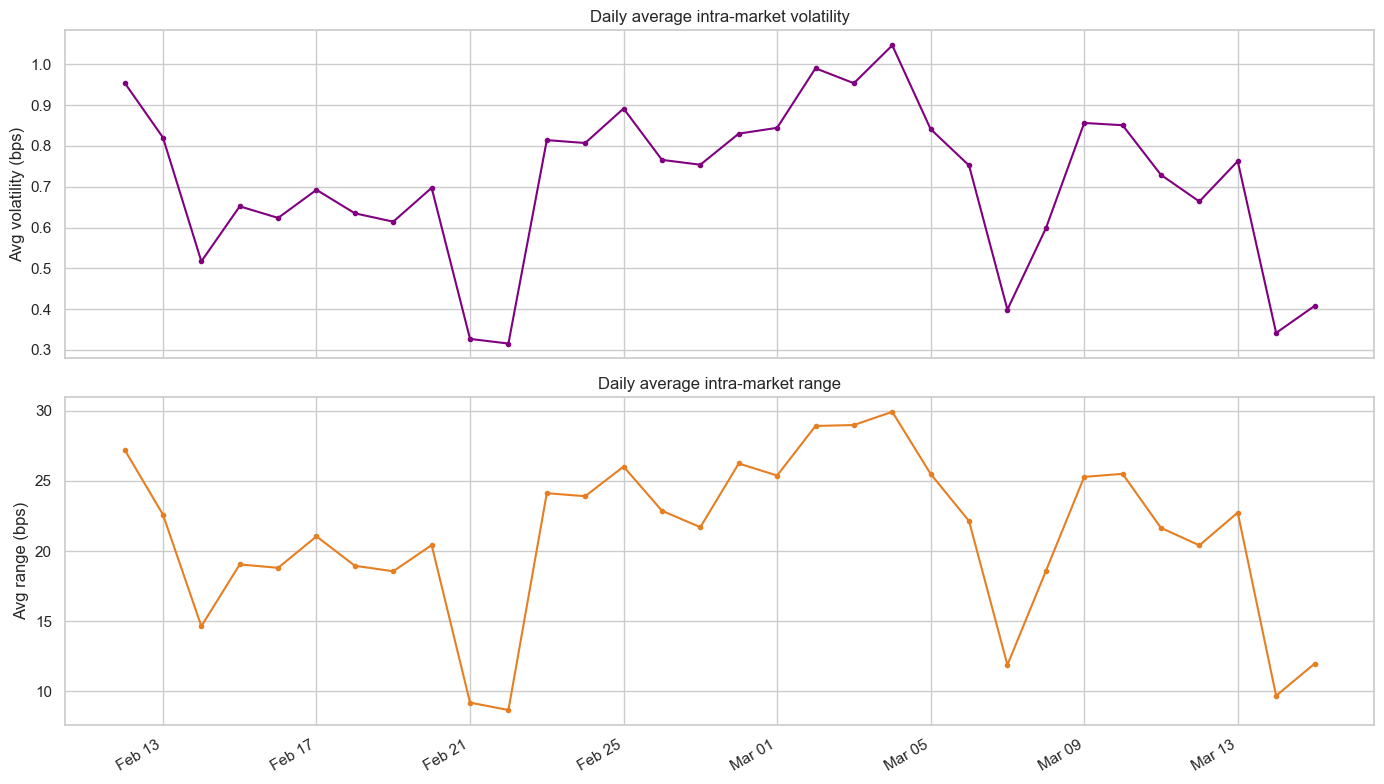

In [47]:
daily_stats = df.groupby("date").agg(
    avg_volatility=("btc_volatility", "mean"),
    avg_range=("btc_range", "mean"),
    avg_volume=("volume", "mean")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_stats.index, daily_stats["avg_volatility"] * 10000, color="purple", marker="o", markersize=3)
axes[0].set_ylabel("Avg volatility (bps)")
axes[0].set_title("Daily average intra-market volatility")

axes[1].plot(daily_stats.index, daily_stats["avg_range"] * 10000, color="#e67e22", marker="o", markersize=3)
axes[1].set_ylabel("Avg range (bps)")
axes[1].set_title("Daily average intra-market range")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## 13. Rolling Up rate over time

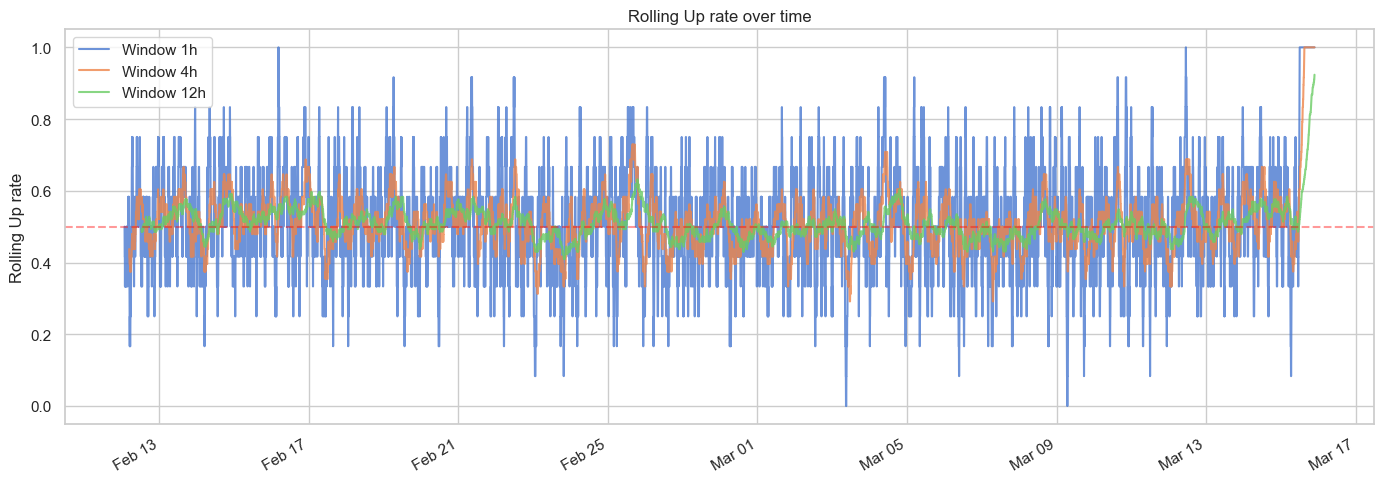

In [48]:
df_sorted = df.sort_values("event_datetime").reset_index(drop=True)

for window in [12, 48, 144]:
    label = f"{window * 5 // 60}h" if window * 5 >= 60 else f"{window * 5}min"
    df_sorted[f"rolling_up_{label}"] = df_sorted["winner_binary"].rolling(window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in [c for c in df_sorted.columns if c.startswith("rolling_up_")]:
    ax.plot(df_sorted["event_datetime"], df_sorted[col], label=col.replace("rolling_up_", "Window "), alpha=0.8)
ax.axhline(0.5, color="red", ls="--", alpha=0.4)
ax.set_ylabel("Rolling Up rate")
ax.set_title("Rolling Up rate over time")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 14. Correlation matrix

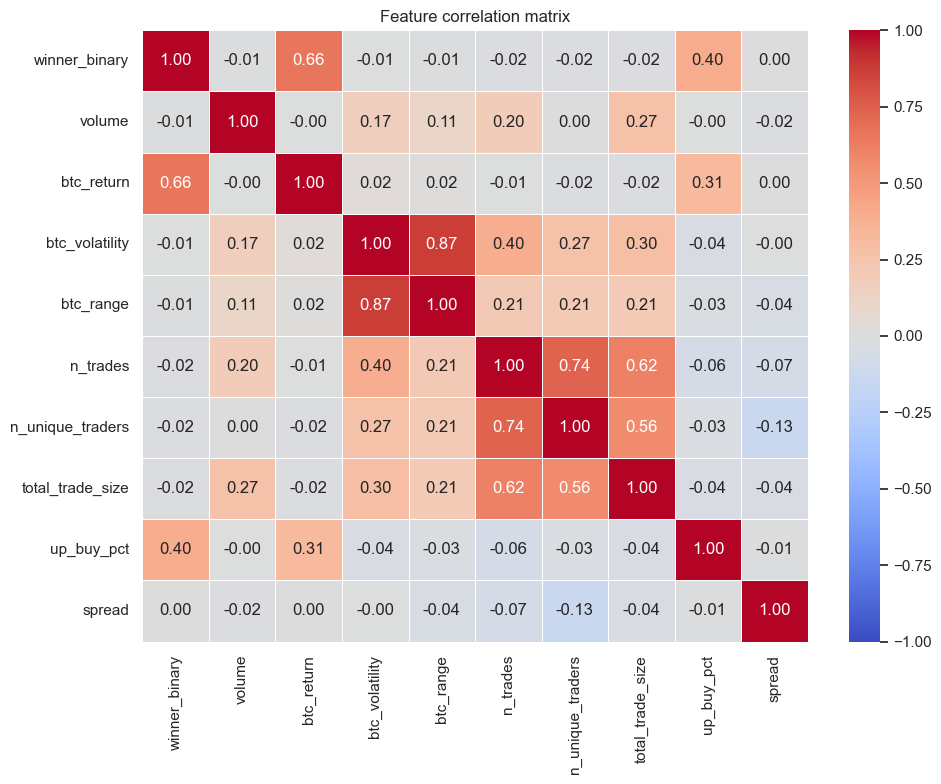

In [49]:
corr_cols = ["winner_binary", "volume", "btc_return", "btc_volatility", "btc_range",
             "n_trades", "n_unique_traders", "total_trade_size", "up_buy_pct", "spread"]
corr_df = df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 15. Key takeaways

In [50]:
print("=== Summary ===")
print(f"Period:            {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Markets:           {len(df):,}")
print(f"Total volume:      ${df['volume'].sum():,.0f}")
print(f"Avg volume/market: ${df['volume'].mean():,.0f}")
print(f"Up rate:           {df['winner_binary'].mean():.1%}")
print(f"All closed:        {df['closed'].all()}")
print(f"BTC range:         ${df['btc_close'].min():,.0f} – ${df['btc_close'].max():,.0f}")
print(f"Mean |return|:     {df['btc_return'].abs().mean()*10000:.2f} bps")
print(f"Avg trades/market: {df['n_trades'].mean():.1f}")
print(f"Avg traders/market:{df['n_unique_traders'].mean():.1f}")

=== Summary ===
Period:            2026-02-12 to 2026-03-15
Markets:           9,181
Total volume:      $686,451,445
Avg volume/market: $74,769
Up rate:           51.4%
All closed:        False
BTC range:         $62,696 – $73,980
Mean |return|:     11.26 bps
Avg trades/market: 1835.1
Avg traders/market:577.2
